## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


## Data loader

In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/rocket_telemetry_project"

with open(f"{PROJECT_ROOT}/src/__init__.py", "w") as f:
    pass

with open(f"{PROJECT_ROOT}/src/data_loader.py", "w") as f:
    f.write('''
import numpy as np
import os

def load_channel(channel_id, data_dir="data"):
    train_path = os.path.join(data_dir, "train", f"{channel_id}.npy")
    test_path = os.path.join(data_dir, "test", f"{channel_id}.npy")
    X_train = np.load(train_path)
    X_test = np.load(test_path)
    print(f"Loaded {channel_id} — Train: {X_train.shape}, Test: {X_test.shape}")
    return X_train, X_test
''')

print("✅Created data_loader.py!")
print("src contents:", os.listdir(f"{PROJECT_ROOT}/src"))

✅Created data_loader.py!
src contents: ['data_loader.ipynb', '__init__.py', '__pycache__', 'data_loader.py']


## All imports

In [ ]:
import os
import sys
import importlib.util
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

PROJECT_ROOT = "/content/drive/MyDrive/rocket_telemetry_project"
os.chdir(PROJECT_ROOT)

# Clean cache
keys_to_delete = [k for k in sys.modules if 'src' in k]
for k in keys_to_delete:
    del sys.modules[k]

sys.path = [p for p in sys.path if p != PROJECT_ROOT]
sys.path.insert(0, PROJECT_ROOT)

# Force load
spec = importlib.util.spec_from_file_location(
    "load_channel",
    f"{PROJECT_ROOT}/src/data_loader.py"
)
data_loader = importlib.util.module_from_spec(spec)
spec.loader.exec_module(data_loader)
load_channel = data_loader.load_channel

print("✅ All imports successful!")


✅ All imports successful!


##  Create directories

In [ ]:
data_dir = "data"
processed_dir = "data/processed"

os.makedirs(processed_dir, exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)

print("✅ Directories ready!")

✅ Directories ready!


## Paths

In [ ]:
data_dir = "data"
processed_dir = "data/processed"

os.makedirs(processed_dir, exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)

## drop_constant_cols

In [ ]:
def drop_constant_cols(X_train, X_test):
    std = np.std(X_train, axis=0)
    col_mask = std > 1e-6
    X_train_clean = X_train[:, col_mask]
    X_test_clean = X_test[:, col_mask]
    dropped = np.sum(~col_mask)
    print(f"{dropped} columns dropped, remaining shape {X_train_clean.shape}")
    return X_train_clean, X_test_clean, col_mask

## Normalize

In [ ]:
def normalize(X_train, X_test, save_path="models/scaler_P1.pkl"):
    scaler = MinMaxScaler(feature_range=(0,1))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    joblib.dump(scaler, save_path)
    assert np.isclose(X_train_scaled.min(),0)
    assert np.isclose(X_train_scaled.max(),1)
    print("Train min:", X_train_scaled.min())
    print("Train max:", X_train_scaled.max())
    return X_train_scaled, X_test_scaled, scaler

## add_delta_features

In [ ]:
def add_delta_features(X):
    delta = np.diff(X, axis=0, prepend=X[[0]])
    X_with_delta = np.concatenate([X, delta], axis=1)
    assert X_with_delta.shape[1] == 2 * X.shape[1]
    return X_with_delta

## add_rolling_features

In [ ]:
def add_rolling_features(X, window=10):
    df = pd.DataFrame(X)
    roll_mean = df.rolling(window, min_periods=1).mean()
    roll_std = df.rolling(window, min_periods=1).std().fillna(0)
    X_with_rolling = np.concatenate(
        [X, roll_mean.values, roll_std.values],
        axis=1
    )
    assert X_with_rolling.shape[1] == 3 * X.shape[1]
    return X_with_rolling

## preprocess_pipeline

In [ ]:
def preprocess_pipeline(channel_id,
                        roll_window=10,
                        data_dir="data",
                        save_dir="data/processed"):
    X_train, X_test = load_channel(channel_id, data_dir)
    raw_train, raw_test = X_train.shape, X_test.shape

    X_train, X_test, col_mask = drop_constant_cols(X_train, X_test)
    drop_train, drop_test = X_train.shape, X_test.shape

    scaler_path = f"models/scaler_{channel_id}.pkl"
    X_train, X_test, scaler = normalize(X_train, X_test, scaler_path)
    norm_train, norm_test = X_train.shape, X_test.shape

    X_train = add_delta_features(X_train)
    X_test = add_delta_features(X_test)
    delta_train, delta_test = X_train.shape, X_test.shape

    X_train = add_rolling_features(X_train, roll_window)
    X_test = add_rolling_features(X_test, roll_window)
    final_train, final_test = X_train.shape, X_test.shape

    os.makedirs(save_dir, exist_ok=True)
    np.save(f"{save_dir}/{channel_id}_train.npy", X_train)
    np.save(f"{save_dir}/{channel_id}_test.npy", X_test)

    print("\nShape progression table")
    print("------------------------------------------")
    print(f"Raw          | {raw_train} | {raw_test}")
    print(f"Drop const   | {drop_train} | {drop_test}")
    print(f"Normalize    | {norm_train} | {norm_test}")
    print(f"Delta        | {delta_train} | {delta_test}")
    print(f"Rolling      | {final_train} | {final_test}")

    return X_train, X_test, scaler, col_mask

## Run Pipeline

In [ ]:
channel_id = "P-1"

X_train_final, X_test_final, scaler, col_mask = preprocess_pipeline(
    channel_id,
    roll_window=10,
    data_dir=data_dir,
    save_dir=processed_dir
)

Loaded P-1 — Train: (2872, 25), Test: (8505, 25)
9 columns dropped, remaining shape (2872, 16)
Train min: 0.0
Train max: 1.0

Shape progression table
------------------------------------------
Raw          | (2872, 25) | (8505, 25)
Drop const   | (2872, 16) | (8505, 16)
Normalize    | (2872, 16) | (8505, 16)
Delta        | (2872, 32) | (8505, 32)
Rolling      | (2872, 96) | (8505, 96)


## LEAKAGE GUARD CELL

### Scaler must only be fitted on TRAIN data.
### This test confirms the scaler parameters come from training statistics.

## LEAKAGE GUARD CELL

In [ ]:
import joblib
import numpy as np

channel_id = "P-1"

# reload scaler
scaler = joblib.load(f"models/scaler_{channel_id}.pkl")

# reload raw data
X_train_raw, X_test_raw = load_channel(channel_id)

# apply same constant-column filtering
X_train_clean, _, _ = drop_constant_cols(X_train_raw, X_test_raw)

# compute statistics from train data
train_min = X_train_clean.min(axis=0)

# verify scaler learned from train data only
assert np.allclose(train_min, scaler.data_min_)

# dummy transform test
dummy = np.zeros((1, scaler.n_features_in_))
_ = scaler.transform(dummy)

print("NO DATA LEAKAGE CONFIRMED")

Loaded P-1 — Train: (2872, 25), Test: (8505, 25)
9 columns dropped, remaining shape (2872, 16)
NO DATA LEAKAGE CONFIRMED


## VISUALIZATION CELL

In [ ]:
channel_id = "P-1"

# raw
X_train_raw, X_test_raw = load_channel(channel_id, data_dir)

# drop constant
X_train_clean, X_test_clean, _ = drop_constant_cols(X_train_raw, X_test_raw)

# normalized
scaler = joblib.load(f"models/scaler_{channel_id}.pkl")

X_train_norm = scaler.transform(X_train_clean)
X_test_norm = scaler.transform(X_test_clean)

# delta features
X_train_delta = add_delta_features(X_train_norm)
X_test_delta = add_delta_features(X_test_norm)

Loaded P-1 — Train: (2872, 25), Test: (8505, 25)
9 columns dropped, remaining shape (2872, 16)


In [ ]:
def preprocess_pipeline(channel_id,
                        roll_window=10,
                        data_dir="data",
                        save_dir="data/processed"):

    print(f"\nProcessing channel {channel_id}")

    # Load data
    X_train, X_test, anomalies = load_channel(channel_id)

    shapes = []
    shapes.append(("Raw", X_train.shape, X_test.shape))

    # Step 1 — Drop constants
    X_train, X_test, col_mask = drop_constant_cols(X_train, X_test)
    shapes.append(("Drop const", X_train.shape, X_test.shape))

    # Step 2 — Normalize
    scaler_path = f"models/scaler_{channel_id}.pkl"

    X_train, X_test, scaler = normalize(
        X_train,
        X_test,
        scaler_path
    )
    shapes.append(("Normalize", X_train.shape, X_test.shape))

    # Step 3 — Delta
    X_train = add_delta_features(X_train)
    X_test = add_delta_features(X_test)
    shapes.append(("Delta", X_train.shape, X_test.shape))

    # Step 4 — Rolling
    X_train = add_rolling_features(X_train, roll_window)
    X_test = add_rolling_features(X_test, roll_window)
    shapes.append(("Rolling", X_train.shape, X_test.shape))

    # Save processed arrays
    os.makedirs(save_dir, exist_ok=True)

    train_path = f"{save_dir}/{channel_id}_train.npy"
    test_path = f"{save_dir}/{channel_id}_test.npy"

    np.save(train_path, X_train)
    np.save(test_path, X_test)

    # ADD THE SHAPE PROGRESSION HERE

    print("\nShape progression")

    print("Stage        | Train shape   | Test shape")
    print("-------------------------------------------")

    for stage_name, train_shape, test_shape in shapes:
        print(f"{stage_name:<12} | {str(train_shape):<13} | {test_shape}")

    # Return outputs
    return X_train, X_test, scaler, col_mask

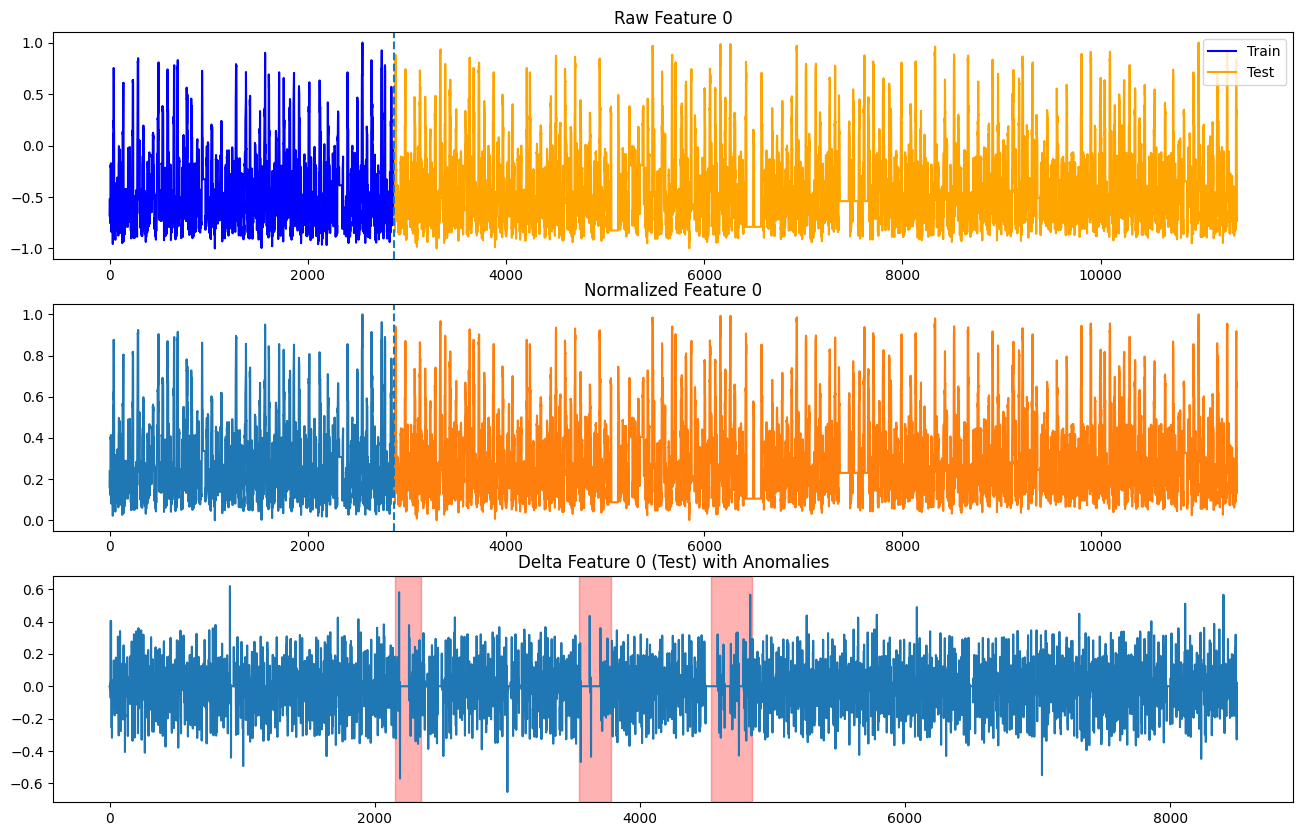

In [ ]:
labels_df = pd.read_csv(f"{data_dir}/labeled_anomalies.csv")

intervals = labels_df[labels_df["chan_id"] == "P-1"]["anomaly_sequences"].values[0]
intervals = eval(intervals)

train_size = len(X_train_raw)

plt.figure(figsize=(16,10))

# Panel 1: RAW DATA
plt.subplot(3,1,1)

plt.plot(X_train_raw[:,0], color="blue", label="Train")

plt.plot(
    range(train_size, train_size + len(X_test_raw)),
    X_test_raw[:,0],
    color="orange",
    label="Test"
)

plt.axvline(train_size, linestyle="--")

plt.title("Raw Feature 0")

plt.legend()


# Panel 2: NORMALIZED
plt.subplot(3,1,2)

plt.plot(X_train_norm[:,0])

plt.plot(
    range(train_size, train_size + len(X_test_norm)),
    X_test_norm[:,0]
)

plt.axvline(train_size, linestyle="--")

plt.title("Normalized Feature 0")


# Panel 3: DELTA TEST
plt.subplot(3,1,3)

# delta features are the second half
delta_feature_index = X_train_norm.shape[1]

delta_test = X_test_delta[:, delta_feature_index]

plt.plot(delta_test)

for start, end in intervals:
    plt.axvspan(start, end, color="red", alpha=0.3)

plt.title("Delta Feature 0 (Test) with Anomalies")


plt.savefig("results/plots/P1_preprocessing.png", dpi=150)

plt.show()